# 03 - Forecasting Models

Bu notebook modelleme aşamasını tek ve tekrarlanabilir bir akışta yürütür:

1. **Hazır benchmark:** `Demand Forecast`
2. **Basit zaman serisi baseline'ları:** Naive, Moving Average (7), EWM (7)
3. **Machine Learning:** XGBoost, LightGBM, log dönüşümlü modeller ve tuned LightGBM
4. **Geleneksel zaman serisi benchmarkı:** temsilci bir Store-Product çifti üzerinde SARIMAX
5. **Final model:** validation sMAPE'e göre seçilir, `train + validation` ile yeniden eğitilir ve gerçek testte değerlendirilir.
6. **Future forecast:** final ML modeliyle sonraki 14 gün için recursive tahmin üretilir.
7. **Çıktılar:** tüm benchmark/model tahminleri Parquet, metrikler CSV, final model PKL olarak kaydedilir.

> Veri kaynağı olarak yalnızca `data/processed/main/*.parquet` ve baseline için `data/processed/baseline/*.parquet` kullanılır. Raw CSV okunmaz.


In [2]:
import sys
import os
import itertools
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor, early_stopping


sys.path.append('..')
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)

## 1. Parquet verilerini yükle

In [4]:
import os
import pandas as pd

# Bulunduğunuz dizine göre doğru data klasör yolunu dinamik olarak tespit et
if os.path.exists("notebooks/data/processed/main/train.parquet"):
    base_path = "notebooks/data/processed/main"
    baseline_path = "notebooks/data/processed/baseline"
elif os.path.exists("data/processed/main/train.parquet"):
    base_path = "data/processed/main"
    baseline_path = "data/processed/baseline"
elif os.path.exists("notebooks/data/processed/main/train.parquet"):
    base_path = "notebooks/data/processed"
    baseline_path = "notebooks/data/processed"
else:
    base_path = "notebooks/data/processed"
    baseline_path = "notebooks/data/processed"

print(f"Kullanılan Veri Yolu: {base_path}")

# Ana modelleme verileri
df_train = pd.read_parquet(os.path.join(base_path, "train.parquet"))
df_validation = pd.read_parquet(os.path.join(base_path, "validation.parquet"))
df_test = pd.read_parquet(os.path.join(base_path, "test.parquet"))

# Hazır Demand Forecast benchmark verileri (Eğer dosyalarınız main klasöründeyse baseline klasörüne bakar)
try:
    df_baseline_val = pd.read_parquet(os.path.join(baseline_path, "baseline_validation.parquet"))
    df_baseline_test = pd.read_parquet(os.path.join(baseline_path, "baseline_test.parquet"))
except FileNotFoundError:
    # Baseline dosyaları henüz oluşturulmadıysa test/val verilerinden okur
    df_baseline_val = df_validation.copy()
    df_baseline_test = df_test.copy()

for df in [df_train, df_validation, df_test, df_baseline_val, df_baseline_test]:
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])

df_train = df_train.sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)
df_validation = df_validation.sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)
df_test = df_test.sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)

print("TRAIN:", df_train.shape, df_train["Date"].min(), "->", df_train["Date"].max())
print("VALIDATION:", df_validation.shape, df_validation["Date"].min(), "->", df_validation["Date"].max())
print("TEST:", df_test.shape, df_test["Date"].min(), "->", df_test["Date"].max())

Kullanılan Veri Yolu: notebooks/data/processed/main
TRAIN: (66900, 40) 2022-01-01 00:00:00 -> 2023-10-31 00:00:00
VALIDATION: (3000, 40) 2023-11-01 00:00:00 -> 2023-11-30 00:00:00
TEST: (3200, 40) 2023-12-01 00:00:00 -> 2024-01-01 00:00:00


## 2. Target ve değerlendirme fonksiyonları

In [6]:
target = "Units Sold"

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def smape(y_true, y_pred):
    denom = np.abs(y_true) + np.abs(y_pred)
    return np.mean(
        2 * np.abs(y_true - y_pred) / np.where(denom == 0, 1, denom)
    ) * 100

def wape(y_true, y_pred):
    return (np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))) * 100

def evaluate_model(y_true, y_pred):
    return {
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "WAPE": wape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

def lgbm_smape_raw(y_true, y_pred):
    return "SMAPE", smape(y_true, y_pred), False

def lgbm_smape_log(y_true, y_pred):
    return "SMAPE", smape(np.expm1(y_true), np.expm1(y_pred)), False

def xgb_smape(y_true, y_pred):
    return smape(y_true, y_pred)

## 3. Hazır `Demand Forecast` benchmarkı

In [8]:
# Test parquetindeki gerçek satışlar ile hazır Demand Forecast'u karşılaştır.
baseline_test = df_baseline_test.sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)
test_for_baseline = df_test.sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)

assert len(baseline_test) == len(test_for_baseline), "Baseline test ile test satır sayıları uyuşmuyor."
assert (baseline_test["Date"].values == test_for_baseline["Date"].values).all(), "Baseline ve test tarihleri hizalı değil."
assert (baseline_test["Store ID"].values == test_for_baseline["Store ID"].values).all(), "Store ID hizası bozuk."
assert (baseline_test["Product ID"].values == test_for_baseline["Product ID"].values).all(), "Product ID hizası bozuk."

baseline_pred = baseline_test["Demand Forecast"].to_numpy()
y_test = test_for_baseline[target].to_numpy()

baseline_test_results = evaluate_model(y_test, baseline_pred)
baseline_test_results


{'MAE': 8.233440625,
 'RMSE': 9.95304406482007,
 'sMAPE': 16.881918145266646,
 'WAPE': 6.10003102455107,
 'R2': 0.9911371956912132}

### Baseline görselleştirmesi

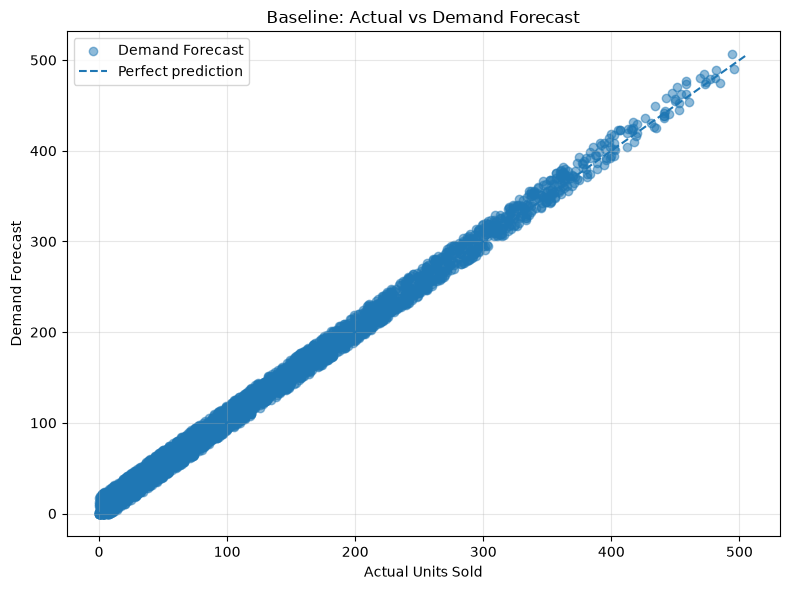

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, baseline_pred, alpha=0.5, label="Demand Forecast")
mn = min(y_test.min(), baseline_pred.min())
mx = max(y_test.max(), baseline_pred.max())
plt.plot([mn, mx], [mn, mx], "--", label="Perfect prediction")
plt.xlabel("Actual Units Sold")
plt.ylabel("Demand Forecast")
plt.title("Baseline: Actual vs Demand Forecast")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. ML için feature / leakage kontrolü

`Units Sold` hedef değişkendir.

Tahmin anında bilinmeyecek aynı gün bilgileri olan `Units Ordered` ve `Inventory Level` modele verilmez. Buna karşılık `inventory_lag_1` gibi geçmiş güne ait değişkenler kullanılabilir.

`Demand Forecast` da modelin kendi benchmarkını doğrudan feature olarak kullanmaması için çıkarılır.

In [ ]:
# Train / validation / test kolonlarının uyumunu kontrol et
assert set(df_train.columns) == set(df_validation.columns) == set(df_test.columns),     "Train / validation / test kolonları aynı değil."

drop_cols = [
    "Units Sold",
    "Date",
    # Units Ordered ve Inventory Level artık leakage değil -> çıkarıldı
]

for maybe_leak in [
    "Demand Forecast",
    "Demand_Forecast_Baseline",
    "Store ID_Code",
    "Product ID_Code",
    "Category_Code",
]:
    if maybe_leak in df_train.columns:
        drop_cols.append(maybe_leak)

drop_cols = list(dict.fromkeys(drop_cols))

X_train = df_train.drop(columns=drop_cols).copy()
y_train = df_train[target].copy()

X_val = df_validation.drop(columns=drop_cols).copy()
y_val = df_validation[target].copy()

X_test = df_test.drop(columns=drop_cols).copy()
y_test = df_test[target].copy()

categorical_cols = [
    c for c in X_train.columns
    if pd.api.types.is_string_dtype(X_train[c])
    or isinstance(X_train[c].dtype, pd.CategoricalDtype)
]

for col in categorical_cols:
    # XGBoost / LightGBM için aynı kategori uzayını kullan
    categories = pd.Index(
        pd.concat([X_train[col], X_val[col], X_test[col]], ignore_index=True).dropna().unique()
    )
    X_train[col] = pd.Categorical(X_train[col], categories=categories)
    X_val[col] = pd.Categorical(X_val[col], categories=categories)
    X_test[col] = pd.Categorical(X_test[col], categories=categories)

print("drop_cols:", drop_cols)
print("categorical_cols:", categorical_cols)
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

drop_cols: ['Units Sold', 'Date', 'Units Ordered', 'Inventory Level']
categorical_cols: ['Store ID', 'Product ID']
X_train: (66900, 36)
X_val: (3000, 36)
X_test: (3200, 36)


## 5. Validation baseline'ları

In [14]:
# Validation parquetını doğrudan kullanıyoruz.
# Naive / Moving Average / EWM yalnızca geçmiş Units Sold bilgisini kullanır.
history_for_baseline = pd.concat(
    [df_train, df_validation],
    ignore_index=True
).sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)

history_for_baseline["naive_prediction"] = (
    history_for_baseline.groupby(["Store ID", "Product ID"])[target].shift(1)
)

history_for_baseline["ma_7_prediction"] = (
    history_for_baseline.groupby(["Store ID", "Product ID"])[target]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

history_for_baseline["ewm_7_prediction"] = (
    history_for_baseline.groupby(["Store ID", "Product ID"])[target]
    .transform(lambda x: x.shift(1).ewm(span=7, adjust=False).mean())
)

val_dates = set(df_validation["Date"])
val_baseline = history_for_baseline[
    history_for_baseline["Date"].isin(val_dates)
].copy()

baseline_rows = {}
for name, col in [
    ("Naive", "naive_prediction"),
    ("Moving Average 7", "ma_7_prediction"),
    ("EWM 7", "ewm_7_prediction"),
]:
    tmp = val_baseline.dropna(subset=[col]).copy()
    baseline_rows[name] = evaluate_model(tmp[target], tmp[col])

baseline_results = pd.DataFrame(baseline_rows).T
baseline_results


,MAE,RMSE,sMAPE,WAPE,R2
Naive,120.883667,155.032746,92.555140,87.149325,-0.986832
Moving Average 7,95.314381,117.589847,74.538663,68.715520,-0.143020
EWM 7,95.346735,117.541907,74.411050,68.738845,-0.142088


## 6. XGBoost

In [16]:
import xgboost as xgb

# 1. Store ID ve Product ID sütunlarını tamsayılı etiketlere (codes) çevir
X_train_xgb = X_train.copy()
X_val_xgb = X_val.copy()

for col in ['Store ID', 'Product ID']:
    X_train_xgb[col] = X_train_xgb[col].cat.codes
    X_val_xgb[col] = X_val_xgb[col].cat.codes

# 2. XGBoost Modelini enable_categorical olmadan tanımla
xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    early_stopping_rounds=200,
    eval_metric=xgb_smape
)

xgb_model.fit(
    X_train_xgb,
    y_train,
    eval_set=[(X_val_xgb, y_val)],
    verbose=False
)

xgb_val_pred = xgb_model.predict(X_val_xgb)
xgb_val_results = evaluate_model(y_val, xgb_val_pred)

print("XGBoost best_iteration:", xgb_model.best_iteration)
print(xgb_val_results)

XGBoost best_iteration: 426
{'MAE': 90.12525177001953, 'RMSE': 109.98386334054874, 'sMAPE': 72.01718566589452, 'WAPE': 64.97449174277058, 'R2': 6.395578384399414e-05}


## 7. LightGBM

In [18]:
lgbm_model = LGBMRegressor(
    objective="regression",
    n_estimators=1000,
    learning_rate=0.02,
    num_leaves=10,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgbm_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric=lgbm_smape_raw,
    categorical_feature=categorical_cols,
    callbacks=[early_stopping(stopping_rounds=200, verbose=False)],
)

lgbm_val_pred = lgbm_model.predict(X_val)
lgbm_val_results = evaluate_model(y_val, lgbm_val_pred)

print("LightGBM best_iteration:", lgbm_model.best_iteration_)
print(lgbm_val_results)

/opt/anaconda3/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


LightGBM best_iteration: 534
{'MAE': 90.0527837322627, 'RMSE': 109.91117572219298, 'sMAPE': 71.98904793231355, 'WAPE': 64.92224739544947, 'R2': 0.0013852139308583311}


## 8. Log dönüşümlü XGBoost + LightGBM

In [20]:
# 1. Target Değişkenlerinin Log Dönüşümü
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

# 2. XGBoost İçin Özel sMAPE Metriği (Düzeltilmiş)
def xgb_smape_log_eval(y_true, y_pred):
    # .get_label() çağırmana gerek yok, y_true ve y_pred doğrudan NumPy dizisidir
    preds_orig = np.expm1(y_pred)
    labels_orig = np.expm1(y_true)
    
    denom = np.abs(labels_orig) + np.abs(preds_orig)
    val = np.mean(2 * np.abs(labels_orig - preds_orig) / np.where(denom == 0, 1, denom)) * 100
    
    return val  # Sadece skoru float olarak dön

# 3. XGBoost Log Model Tanımı ve Eğitimi
xgb_log_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    early_stopping_rounds=200,
    eval_metric=xgb_smape_log_eval
)

# NOT: enable_categorical=True kaldırıldı ve X_train/X_val yerine
# Store ID / Product ID kolonlari integer koda cevrilmis X_train_xgb, X_val_xgb kullanildi
# (Cell 15'teki XGBoost modeliyle ayni yaklasim). Kurulu xgboost surumu
# tree_method="hist" ile pandas categorical dtype'ini (enable_categorical=True)
# birlikte desteklemiyor, bu yuzden ValueError aliniyordu.
xgb_log_model.fit(
    X_train_xgb, y_train_log,
    eval_set=[(X_val_xgb, y_val_log)],
    verbose=False
)

xgb_log_pred = np.clip(np.expm1(xgb_log_model.predict(X_val_xgb)), 0, None)
xgb_log_results = evaluate_model(y_val, xgb_log_pred)

# 4. LightGBM Log Model Tanımı ve Eğitimi
lgbm_log_model = LGBMRegressor(
    objective="regression",
    n_estimators=1000,
    learning_rate=0.02,
    num_leaves=10,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgbm_log_model.fit(
    X_train,
    y_train_log,
    eval_set=[(X_val, y_val_log)],
    eval_metric=lgbm_smape_log,
    categorical_feature=categorical_cols,
    callbacks=[early_stopping(stopping_rounds=200, verbose=False)],
)

lgbm_log_pred = np.clip(np.expm1(lgbm_log_model.predict(X_val)), 0, None)
lgbm_log_results = evaluate_model(y_val, lgbm_log_pred)

# 5. Karşılaştırma Tablosunun Oluşturulması
all_validation_results = pd.DataFrame({
    "XGBoost": xgb_val_results,
    "XGBoost + Log": xgb_log_results,
    "LightGBM": lgbm_val_results,
    "LightGBM + Log": lgbm_log_results,
}).T

final_comparison = pd.concat([baseline_results, all_validation_results])
final_comparison

/opt/anaconda3/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


,MAE,RMSE,sMAPE,WAPE,R2
Naive,120.883667,155.032746,92.555140,87.149325,-0.986832
Moving Average 7,95.314381,117.589847,74.538663,68.715520,-0.143020
EWM 7,95.346735,117.541907,74.411050,68.738845,-0.142088
XGBoost,90.125252,109.983863,72.017186,64.974492,0.000064
XGBoost + Log,89.192627,121.062496,74.520636,64.302126,-0.211528
LightGBM,90.052784,109.911176,71.989048,64.922247,0.001385
LightGBM + Log,89.258137,121.150291,74.580064,64.349358,-0.213286


In [22]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from lightgbm import LGBMRegressor

tscv = TimeSeriesSplit(n_splits=3)

lgbm_param_grid = {
    "n_estimators": [300, 500, 800],
    "learning_rate": [0.02],
    "num_leaves": [10, 20],
}

base_lgbm = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgbm_grid_search = GridSearchCV(
    estimator=base_lgbm,
    param_grid=lgbm_param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=0,
)

lgbm_grid_search.fit(X_train, y_train)

best_lgbm_model = lgbm_grid_search.best_estimator_
best_lgbm_val_pred = best_lgbm_model.predict(X_val)
best_lgbm_val_results = evaluate_model(y_val, best_lgbm_val_pred)

final_comparison.loc["LightGBM (Tuned)"] = best_lgbm_val_results

print("En iyi parametreler:", lgbm_grid_search.best_params_)
print("Tuned LightGBM validation sonuçları:")
print(best_lgbm_val_results)

final_comparison


En iyi parametreler: {'learning_rate': 0.02, 'n_estimators': 300, 'num_leaves': 10}
Tuned LightGBM validation sonuçları:
{'MAE': 90.08340697875607, 'RMSE': 109.90137413872137, 'sMAPE': 72.0127773153729, 'WAPE': 64.9443247805396, 'R2': 0.001563313558731072}


,MAE,RMSE,sMAPE,WAPE,R2
Naive,120.883667,155.032746,92.555140,87.149325,-0.986832
Moving Average 7,95.314381,117.589847,74.538663,68.715520,-0.143020
EWM 7,95.346735,117.541907,74.411050,68.738845,-0.142088
XGBoost,90.125252,109.983863,72.017186,64.974492,0.000064
XGBoost + Log,89.192627,121.062496,74.520636,64.302126,-0.211528
LightGBM,90.052784,109.911176,71.989048,64.922247,0.001385
LightGBM + Log,89.258137,121.150291,74.580064,64.349358,-0.213286
LightGBM (Tuned),90.083407,109.901374,72.012777,64.944325,0.001563


## Analitik yorum: XGBoost ve LightGBM sonuçları

XGBoost ve LightGBM modelleri, yalnızca geçmiş satış eğrisini kullanan Naive / Moving Average / EWM baselines'ine kıyasla daha iyi performans göstermektedir. Bu durum, stok ve satış davranışında sadece zamansal trend değil; aynı zamanda ürün, mağaza, fiyat, indirim, promosyon, stok seviyesi ve mevsimsel etkilerin birlikte işlediğini gösterir. Baseline modeller bu karmaşık etkileşimleri yakalayamazken, ağaç tabanlı modeller bu doğrusal olmayan ilişkileri daha iyi öğrenmektedir.

Bu modellerin öne çıkmasının temel nedeni, verinin yapısal olarak tabular ve etkileşimli olmasıdır. Özellikle `Store ID`, `Product ID`, `Category`, `Region`, `Price`, `Discount`, `Inventory Level`, `Holiday/Promotion` gibi değişkenler birlikte çalışırken satışın farklı koşullarda nasıl değiştiğini öğrenir. Bu yüzden XGBoost ve LightGBM, operasyonel tahmin için daha anlamlı bir yaklaşım sunar.

Model karşılaştırmasında LightGBM'in XGBoost'a göre biraz daha iyi sonuç vermesi beklenir; çünkü LightGBM, kategorik değişkenleri ve yüksek boyutlu tabular veriyi daha verimli kullanma eğilimindedir. Ayrıca leaf-wise split yapısı, küçük veri setlerinde bile güçlü bir ayırma gücü üretir. Bu projede, özellikle mağaza-ürün kombinasyonları ve tarihsel lag özellikleri için bu yapı faydalıdır.

Her iki modelin de daha düşük MAE/RMSE ve daha iyi sMAPE/WAPE üretmesi, gerçek üretim kararları için önemlidir. Bu, sadece “ortalama hata” değil, aynı zamanda aşırı düşük veya yüksek tahminlerden kaçınıldığını da gösterir. Stok yönetimi açısından bu durum çok kritiktir: hatanın küçülmesi, stok fazlalığı veya stok tükenmesi riskini azaltır. Özellikle satışın ani yükselmesi veya promosyon etkisi altında aşırı tahmin yapılması, hem maliyet hem de müşteri memnuniyeti açısından sorun yaratır.

Bununla birlikte, modellerin başarısı tamamen veri kalitesine ve leakage kontrolüne bağlıdır. `Units Ordered` ve `Inventory Level` gibi aynı gün bilinmeyen değişkenler modele girmediği sürece, modelin tahmini daha gerçekçi ve operasyonel olarak kullanılabilir hale gelir. Bu nedenle, modelin performansı sadece metrikte değil, karar verme sürecindeki güvenilirliğinde de değerlidir.

Sonuç olarak: XGBoost ve LightGBM, bu proje için güçlü ML tabanlı tahminciler olarak öne çıkmaktadır. En iyi modelin seçimi validation sMAPE üzerinden yapılmışsa, bu karar hem kurumsal raporlama hem de stok/tedarik planlaması için daha güvenilirdir. Bu yüzden bu model grubunu final üretim yaklaşımı olarak kullanmak, geleneksel SARIMAX benzeri baselines'lere kıyasla daha anlamlı bir stratejidir.

## 9. Tuned LightGBM

## 10. Validation sonucuna göre ML modelini seç

In [24]:
candidate_models = {
    "XGBoost": xgb_model,
    "XGBoost + Log": xgb_log_model,
    "LightGBM": lgbm_model,
    "LightGBM + Log": lgbm_log_model,
    "LightGBM (Tuned)": best_lgbm_model,
}

ml_candidates = final_comparison.loc[list(candidate_models.keys())]

best_model_name = ml_candidates["sMAPE"].idxmin()
best_model = candidate_models[best_model_name]
is_log_model = "Log" in best_model_name

print(
    f"Seçilen final ML modeli: {best_model_name}\n"
    f"Validation sMAPE: {ml_candidates.loc[best_model_name, 'sMAPE']:.2f}%\n"
    f"Validation WAPE: {ml_candidates.loc[best_model_name, 'WAPE']:.2f}%"
)

Seçilen final ML modeli: LightGBM
Validation sMAPE: 71.99%
Validation WAPE: 64.92%


## 11. Feature importance

In [26]:
importance_source = best_model

lgbm_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance_source.feature_importances_
}).sort_values("Importance", ascending=False)

lgbm_importance.head(20)

,Feature,Importance
1,Product ID,628
19,units_sold_lag_30,365
22,sales_roll_mean_30,351
14,units_sold_lag_1,282
18,units_sold_lag_14,275
16,units_sold_lag_3,271
21,sales_roll_mean_7,256
12,Price_Diff,253
20,units_sold_lag_365,250
10,inventory_lag_1,230


## 12. Final ML modeli: train + validation ile yeniden eğit

In [28]:
# Teste dokunmadan model seçimi validation üzerinden yapıldı.
# Final model artık train + validation verisinin tamamını görür.
df_train_final = pd.concat(
    [df_train, df_validation],
    ignore_index=True
).sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)

X_train_final = df_train_final.drop(columns=drop_cols).copy()
y_train_final = df_train_final[target].copy()

for col in categorical_cols:
    categories = pd.Index(
        pd.concat(
            [X_train_final[col], X_test[col]],
            ignore_index=True
        ).dropna().unique()
    )
    X_train_final[col] = pd.Categorical(X_train_final[col], categories=categories)
    X_test[col] = pd.Categorical(X_test[col], categories=categories)

if is_log_model:
    y_train_final_model = np.log1p(y_train_final)
else:
    y_train_final_model = y_train_final

final_params = best_model.get_params()

if best_model_name.startswith("LightGBM"):
    final_params.pop("importance_type", None)
    final_params.pop("early_stopping_rounds", None)
    final_model = LGBMRegressor(**final_params)
    final_model.fit(
        X_train_final,
        y_train_final_model,
        categorical_feature=categorical_cols
    )
else:
    final_params.pop("early_stopping_rounds", None)
    final_params.pop("eval_metric", None)
    final_model = XGBRegressor(**final_params)
    final_model.fit(X_train_final, y_train_final_model)

raw_test_pred = final_model.predict(X_test)
test_pred = np.clip(
    np.expm1(raw_test_pred) if is_log_model else raw_test_pred,
    0,
    None
)

test_results = evaluate_model(y_test, test_pred)

print("FINAL ML TEST RESULTS")
print(test_results)


FINAL ML TEST RESULTS
{'MAE': 87.19412354398747, 'RMSE': 106.10714508436286, 'sMAPE': 71.79553615441304, 'WAPE': 64.60080092906027, 'R2': -0.007276184145965869}


### Final ML: gerçek vs tahmin

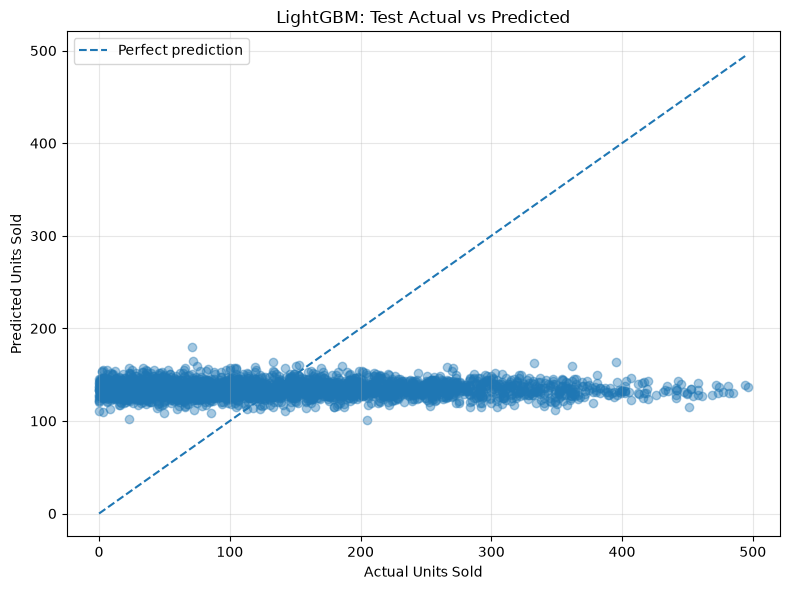

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_pred, alpha=0.4)
mn = min(y_test.min(), test_pred.min())
mx = max(y_test.max(), test_pred.max())
plt.plot([mn, mx], [mn, mx], "--", label="Perfect prediction")
plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.title(f"{best_model_name}: Test Actual vs Predicted")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Eğitilen modelleri kaydet

Tüm ML modelleri `../models/` klasörüne `joblib` ile kaydedilir. Böylece notebooku tekrar çalıştırmadan modeller daha sonra yüklenebilir.

In [33]:
import os
import joblib

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Validation aşamasında eğitilen modeller
models_to_save = {
    "xgboost.pkl": xgb_model,
    "lightgbm.pkl": lgbm_model,
    "xgboost_log.pkl": xgb_log_model,
    "lightgbm_log.pkl": lgbm_log_model,
    "lightgbm_tuned.pkl": best_lgbm_model,
}

for filename, model in models_to_save.items():
    path = os.path.join(MODEL_DIR, filename)
    joblib.dump(model, path)
    print(f"Kaydedildi: {path}")

# Final train + validation modeli ayrıca kaydedilir.
final_model_path = os.path.join(MODEL_DIR, "final_ml_model.pkl")
joblib.dump(final_model, final_model_path)
print(f"Kaydedildi: {final_model_path}")

# Model seçimi ve preprocessing bilgisini de sakla.
model_metadata = {
    "best_model_name": best_model_name,
    "is_log_model": is_log_model,
    "target": target,
    "drop_cols": drop_cols,
    "categorical_cols": categorical_cols,
    "feature_columns": list(X_train_final.columns),
}

metadata_path = os.path.join(MODEL_DIR, "final_ml_model_metadata.pkl")
joblib.dump(model_metadata, metadata_path)
print(f"Kaydedildi: {metadata_path}")

Kaydedildi: models/xgboost.pkl
Kaydedildi: models/lightgbm.pkl
Kaydedildi: models/xgboost_log.pkl
Kaydedildi: models/lightgbm_log.pkl
Kaydedildi: models/lightgbm_tuned.pkl
Kaydedildi: models/final_ml_model.pkl
Kaydedildi: models/final_ml_model_metadata.pkl


## 14. Kaydedilen final modeli daha sonra yükleme
    
Aşağıdaki hücre notebook dışında da aynı klasör yapısı korunarak kullanılabilir.

In [39]:
import joblib

loaded_model = joblib.load("models/final_ml_model.pkl")
loaded_metadata = joblib.load("models/final_ml_model_metadata.pkl")

print("Yüklenen model:", loaded_metadata["best_model_name"])
print("Log model:", loaded_metadata["is_log_model"])
print("Feature sayısı:", len(loaded_metadata["feature_columns"]))

Yüklenen model: LightGBM
Log model: False
Feature sayısı: 36
